## Task Overview

In this lab you will use a **Long Short-Term Memory (LSTM)** network to forecast a
**time series**: monthly totals of international airline passengers from 1949 to
1960 ([Airline Passengers dataset](https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv)).

**After completing this task, you will know how to:**

- Load a time series and prepare it for a recurrent network
- Scale the data correctly (using training statistics only)
- Turn a sequence into **sliding windows** of (past values -> next value)
- Build and train an LSTM for one-step forecasting
- Evaluate the forecast and plot predictions against the real values

**How it's different from image classification:** with time series the **order
matters**. We split the data by time (not randomly), fit the scaler on the
training portion only, and predict a continuous number (regression) instead of a
class.

## Task

Follow the instructions below to complete your coding assignment.

Run the code in the sections beginning with "Static" unchanged, unless otherwise
indicated. Fill in every cell marked `## Answer here`.

### Static code

In [1]:
# @title Importing Necessary Packages

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
# @title Device, seed helper, and data URL

# Use a GPU if one is available, otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def set_seed(seed):
    """Fix all random number generators for reproducible results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# Public URL for the classic Airline Passengers dataset (144 monthly totals).
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

### Task 1
#### **Load and prepare the time series (Steps 1-3)**

In this task you will:

1) Load the Airline Passengers data and plot it.
2) Scale the values and split the series chronologically into train and test.
3) Build sliding-window sequences and wrap them in a `DataLoader`.

#### Step 1: Load and plot the data

Read the CSV from `data_url` with `pandas`. The file has two columns, `Month`
and `Passengers`. Extract the `Passengers` column as a float array called
`series` and plot it. You should see an upward trend with a repeating yearly
(seasonal) pattern.

In [ ]:
## Answer here

# TODO:
# 1) df = pd.read_csv(data_url)
# 2) series = df["Passengers"].values.astype("float32")
# 3) Plot `series` with plt.plot, add xlabel/ylabel/title, then plt.show()

Check: `df.head()` and the month count should print:

         Month  Passengers
    0  1949-01         112
    1  1949-02         118
    2  1949-03         132
    3  1949-04         129
    4  1949-05         121
    Number of months: 144

and the plot of the raw series should look like this — an upward trend with a repeating yearly (seasonal) pattern:

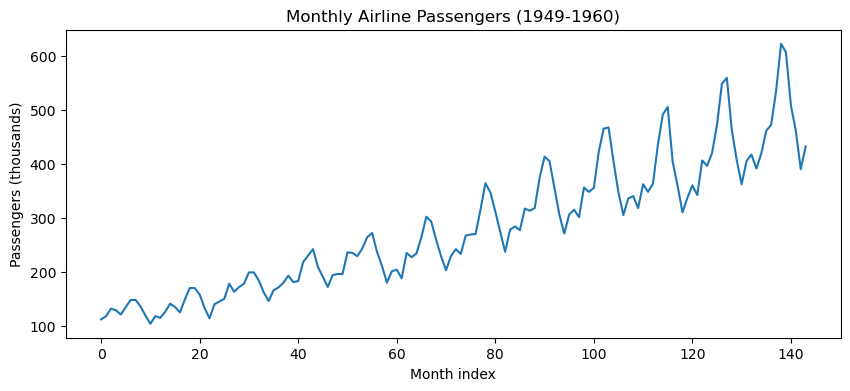

#### Step 2: Scale and split the series

Hold out the **last 12 months** as the test set (`test_size = 12`). Scale the
series to the range [0, 1] using the **minimum and maximum of the training
portion only** -- using the whole series would leak future information into
training. Keep `train_min` and `train_max`; you'll need them to convert
predictions back to real passenger counts later.

In [ ]:
## Answer here

# TODO:
# 1) test_size = 12; split_idx = len(series) - test_size
# 2) train_min = series[:split_idx].min(); train_max = series[:split_idx].max()
# 3) scaled = (series - train_min) / (train_max - train_min)
# 4) train_series = scaled[:split_idx]; test_series = scaled[split_idx:]

Check: You should see:

    Train months: 132 | Test months: 12

#### Step 3: Build sliding windows and a DataLoader

An LSTM learns from short sub-sequences. Use a window of `seq_length = 12`
months: each input `X` is 12 consecutive months and the target `y` is the very
next month. Build these windows, reshape `X` to `(num_windows, seq_length, 1)`
(the LSTM expects a feature dimension), split them into train/test by their
target month, and wrap the training windows in a `DataLoader` (`batch_size = 16`).

In [ ]:
## Answer here

# TODO:
# 1) seq_length = 12
# 2) Write make_windows(data, seq_length) returning arrays X, y where
#    X[i] = data[i:i+seq_length] and y[i] = data[i+seq_length].
# 3) X_all, y_all = make_windows(scaled, seq_length)
# 4) Split windows by target month:
#      target_idx = np.arange(seq_length, len(scaled))
#      train_mask = target_idx < split_idx
#      X_train, y_train = X_all[train_mask], y_all[train_mask]
#      X_test,  y_test  = X_all[~train_mask], y_all[~train_mask]
# 5) Convert to tensors and add a feature dim with .unsqueeze(-1)
#    (y should end up shape (N, 1) too)
# 6) train_ds = TensorDataset(X_train, y_train)
#    train_loader = DataLoader(train_ds, batch_size=16, shuffle=False)

Check: Print the shapes. You should see:

    X_train shape: torch.Size([120, 12, 1])
    y_train shape: torch.Size([120, 1])
    X_test shape:  torch.Size([12, 12, 1])
    y_test shape:  torch.Size([12, 1])

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

### Task 2
#### **Build the LSTM forecasting model**

Define a model class `LSTMForecaster` that:

1) Runs the input sequence through an `nn.LSTM(input_size=1, hidden_size=50,
   batch_first=True)`.
2) Takes the output of the **last timestep** (it has seen the whole window).
3) Passes it through `nn.Linear(50, 1)` to predict the next value.

In [ ]:
## Answer here

# TODO: Complete the LSTMForecaster model.
#
# In __init__ define:
#   self.lstm -> nn.LSTM(input_size=1, hidden_size=50, batch_first=True)
#   self.fc   -> nn.Linear(50, 1)
#
# In forward(x):   # x shape: (B, seq_length, 1)
#   1) out, _ = self.lstm(x)     # out: (B, seq_length, hidden_size)
#   2) last = out[:, -1, :]      # last timestep -> (B, hidden_size)
#   3) return self.fc(last)      # (B, 1)

class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=50):
        super().__init__()
        # TODO: define self.lstm and self.fc
        pass

    def forward(self, x):
        # TODO: implement the forward pass
        pass

Check: Instantiate the model and run 5 windows through it. The output shape
should be `torch.Size([5, 1])` (one predicted value per input window).

In [ ]:
set_seed(1)                       # reproducible weight initialization
model = LSTMForecaster().to(device)
print(model)

# Quick shape test: run 5 windows through the untrained model.
sample = X_train[:5].to(device)
print("Output shape:", model(sample).shape)   # expect torch.Size([5, 1])

### Task 3
#### **Train the model**

Use **mean squared error** (`nn.MSELoss`) since we're predicting a continuous
value, plus the Adam optimizer. This dataset is tiny, so training many epochs is
fast. Print the loss every few epochs.

In [ ]:
## Answer here

# TODO:
# 1) criterion = nn.MSELoss()
# 2) optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# 3) num_epochs = 150. Each epoch:
#      - model.train(); for X_batch, y_batch in train_loader:
#            move to device, zero_grad, preds = model(X_batch),
#            loss = criterion(preds, y_batch), backward, step; accumulate loss.
#      - every 10 epochs, print the average loss.

Check: The loss should fall over training (exact numbers vary a little from run to run), ending well below `0.01` — for example:

    Epoch  10/150 | loss: 0.01432
    Epoch  50/150 | loss: 0.00402
    Epoch 100/150 | loss: 0.00510
    Epoch 150/150 | loss: 0.00113

### Task 4
#### **Evaluate and visualize the forecast**

#### Step 1: Predict and measure error

Put the model in eval mode and predict on `X_test` (inside `torch.no_grad()`).
Convert the predictions and true values back to real passenger counts by
inverting the scaling (`value * (train_max - train_min) + train_min`), then
compute the test **RMSE** (root mean squared error).

In [ ]:
## Answer here

# TODO:
# 1) model.eval(); with torch.no_grad(): predict on X_test.to(device)
# 2) Move the prediction to cpu/numpy and flatten it.
# 3) Write inverse(x) = x * (train_max - train_min) + train_min
# 4) test_pred_real = inverse(pred);  y_test_real = inverse(y_test.numpy().flatten())
# 5) rmse = np.sqrt(np.mean((test_pred_real - y_test_real) ** 2)); print it.

Check: The test error should be roughly:

    Test RMSE: 29.40 thousand passengers

(Your exact value will vary a little depending on training randomness — anything in the ~25-35 range is expected.)

#### Step 2: Plot the forecast

Plot the full actual series, then overlay the model's test predictions on the
final 12 months. Add a vertical line at the train/test boundary so it's clear
which part the model never saw during training.

In [ ]:
## Answer here

# TODO:
# 1) Plot the actual `series` (black line).
# 2) The test predictions line up with month indices split_idx .. len(series)-1:
#      test_months = np.arange(split_idx, len(series))
#    Plot test_pred_real against test_months (red, with markers).
# 3) Add plt.axvline(split_idx, ...) for the boundary, plus labels and a legend.

Check: Your forecast plot should look approximately like this — the red test predictions closely tracking the actual black curve after the train/test split line:

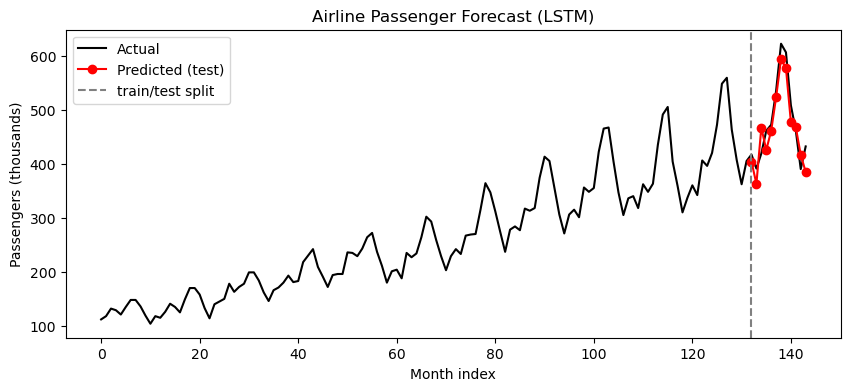